### 1)Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

### 2) Load Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving AI_based_hiring.csv to AI_based_hiring.csv


### Basic Data Analysis (EDA)

In [ ]:
df = pd.read_csv("AI_based_hiring.csv")
df.head()

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


In [ ]:
df.shape

(1000, 11)

In [ ]:
df.columns

Index(['Resume_ID', 'Name', 'Skills', 'Experience (Years)', 'Education',
       'Certifications', 'Job Role', 'Recruiter Decision',
       'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [ ]:
df.describe()

,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100)
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,4.896000,79994.486000,5.13300,83.950000
std,288.819436,3.112695,23048.472549,3.23137,20.983036
min,1.000000,0.000000,40085.000000,0.00000,15.000000
25%,250.750000,2.000000,60415.750000,2.00000,70.000000
50%,500.500000,5.000000,79834.500000,5.00000,100.000000
75%,750.250000,8.000000,99583.250000,8.00000,100.000000
max,1000.000000,10.000000,119901.000000,10.00000,100.000000


missing values

In [ ]:
df.isnull().sum()

,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,274
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


### 4) Data Cleaning

In [ ]:
df.drop(["Resume_ID", "Name"], axis=1, inplace=True)

### 5) Target Variable Encoding

In [ ]:
df["Certifications"] = df["Certifications"].fillna("None")
df

,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,"TensorFlow, NLP, Pytorch",10,B.Sc,None,AI Researcher,Hire,104895,8,100
1,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,"SQL, React, Java",4,PhD,None,Software Engineer,Hire,87441,9,100
...,...,...,...,...,...,...,...,...,...
995,"Cybersecurity, Linux, Ethical Hacking",0,B.Sc,None,Cybersecurity Analyst,Reject,114364,9,60
996,"Deep Learning, Machine Learning",0,MBA,Deep Learning Specialization,Data Scientist,Reject,103294,5,45
997,"TensorFlow, NLP",0,B.Tech,Google ML,AI Researcher,Hire,113855,9,65
998,"Linux, Networking, Cybersecurity, Ethical Hacking",8,PhD,AWS Certified,Cybersecurity Analyst,Hire,83146,10,100


In [ ]:
df["Recruiter Decision"] = df["Recruiter Decision"].map({
    "Hire": 1,
    "Reject": 0
})

In [ ]:
df["Recruiter Decision"].value_counts()

,count
Recruiter Decision,
1,812
0,188


### 6) Feature Engineering

In [ ]:
le = LabelEncoder()
df["Education"] = le.fit_transform(df["Education"])
df["Certifications"] = le.fit_transform(df["Certifications"])
df["Job Role"] = le.fit_transform(df["Job Role"])

### 7) Handle Skills Column

In [ ]:
vectorizer = CountVectorizer()
skills_matrix = vectorizer.fit_transform(df["Skills"])

In [ ]:
skills_df = pd.DataFrame(
    skills_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

In [ ]:
df = df.drop("Skills", axis=1)

In [ ]:
df = pd.concat([df.reset_index(drop=True),
                skills_df.reset_index(drop=True)], axis=1)

### 8) Correlation Analysis

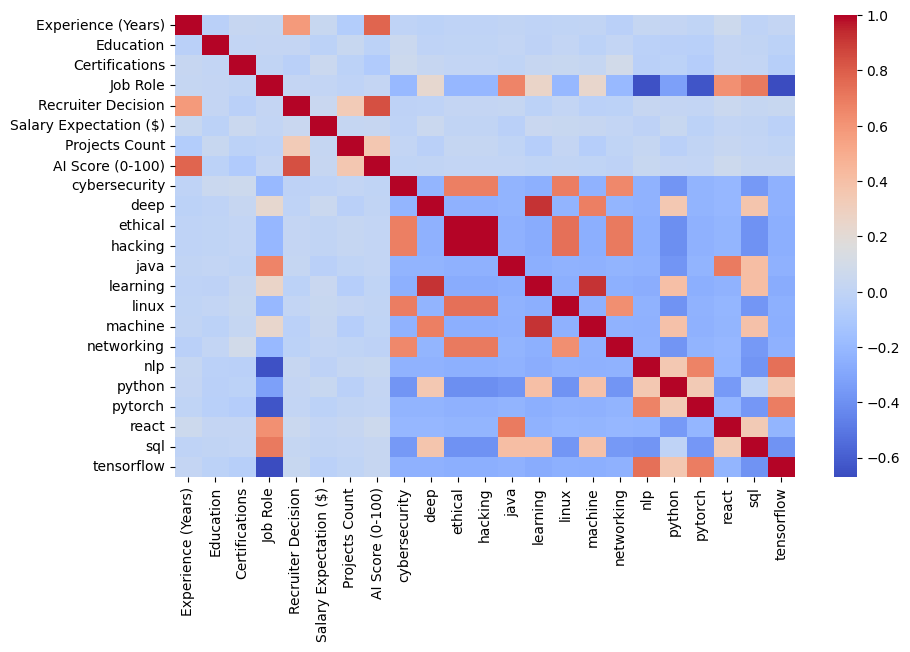

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

### 9) Split Data

In [ ]:
X = df.drop("Recruiter Decision", axis=1)
y = df["Recruiter Decision"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 10) Train ML Model

In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

# 11) Prediction

In [ ]:
y_pred = model.predict(X_test)

# 12) Model Evaluation

In [ ]:
accuracy_score(y_test, y_pred)

1.0

### Classification report:

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        46
           1       1.00      1.00      1.00       154

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



### *Confusion matrix:*

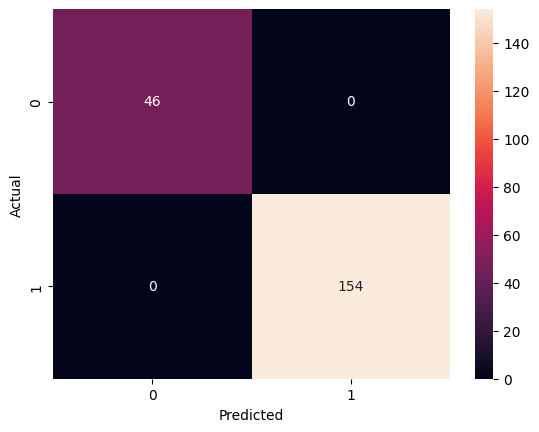

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 13) Feature Importance

In [ ]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

,0
AI Score (0-100),0.584777
Experience (Years),0.224521
Projects Count,0.088114
Salary Expectation ($),0.035118
Education,0.012772
Certifications,0.011873
python,0.004362
sql,0.004028
learning,0.003541
Job Role,0.003459


# 14) Make New Candidate Prediction

In [ ]:
candidate = X.iloc[0:1]
prediction = model.predict(candidate)

if prediction[0] == 1:
    print("Candidate likely to be HIRED")
else:
    print("Candidate likely to be REJECTED")

Candidate likely to be HIRED
